<a href="https://colab.research.google.com/github/lucianoyllarreta/CLASE_CIENCIA_DATOS_I/blob/main/LOS%204%20FANT%C3%81STICOS/Gr%C3%A1ficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
upload  = files.upload()

Saving disuguaglianza-economica-globale-e-povert-1980-2024.csv to disuguaglianza-economica-globale-e-povert-1980-2024.csv


In [ ]:
import pandas as pd
df = pd.read_csv('disuguaglianza-economica-globale-e-povert-1980-2024.csv')

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
evolucion_pbi = df.groupby('year')['gdp'].sum()

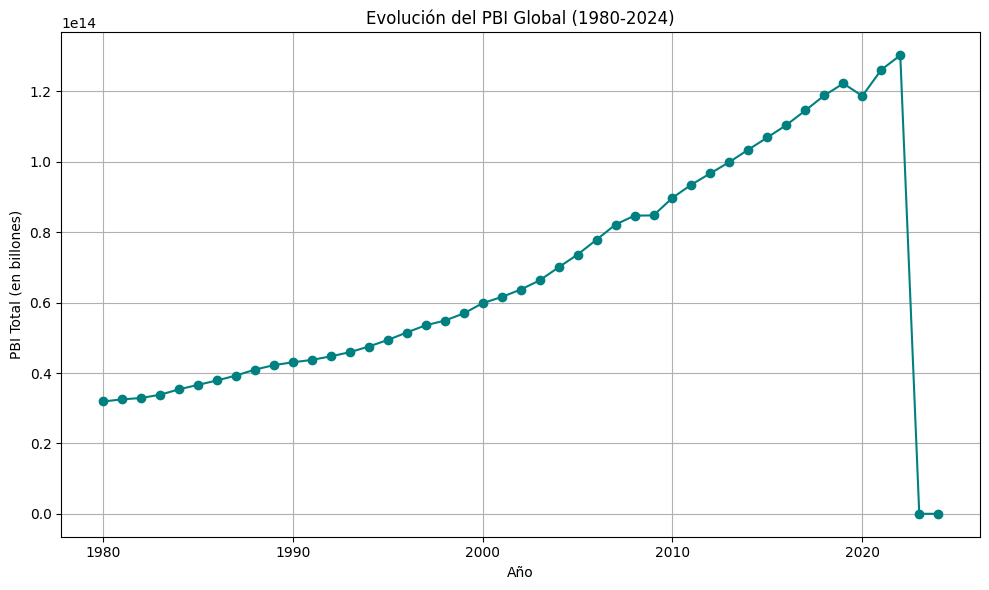

In [ ]:
evolucion_pbi.plot(kind='line',
                   figsize=(10, 6),
                   marker='o',
                   color='teal',
                   grid=True)
plt.title('Evolución del PBI Global (1980-2024)')
plt.xlabel('Año')
plt.ylabel('PBI Total (en billones)')
plt.tight_layout()

/tmp/ipykernel_4155/4043146743.py:2: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['growth_rate'] = df.groupby('country')['gdp_per_capita'].pct_change() * 100


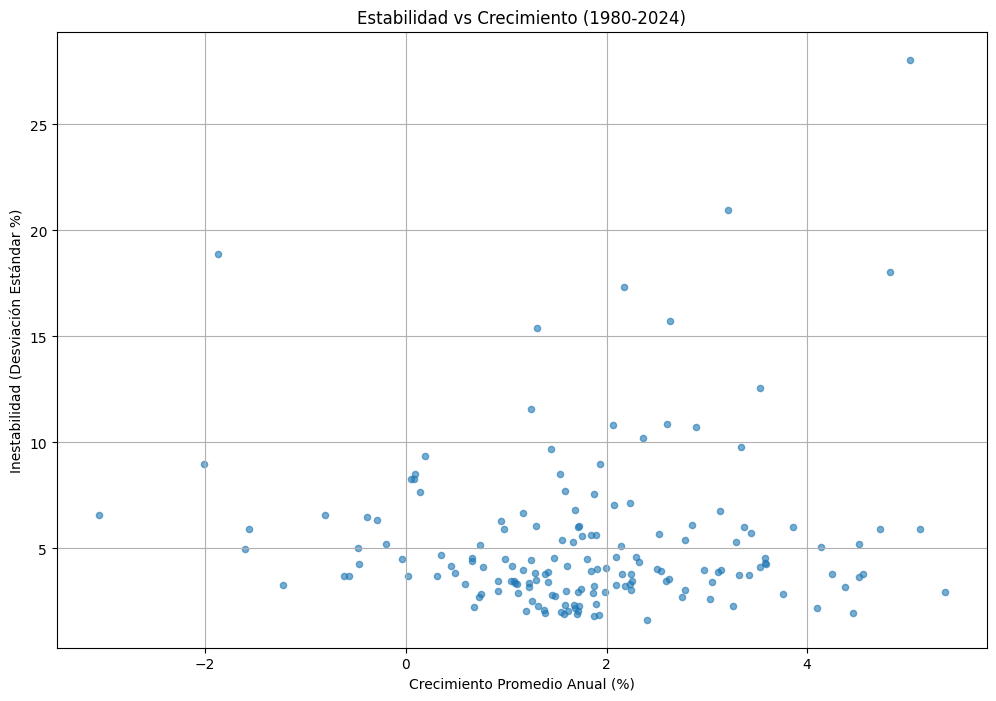

In [ ]:
# Calculamos la tasa de crecimiento anual por país
df['growth_rate'] = df.groupby('country')['gdp_per_capita'].pct_change() * 100

# Agrupamos para obtener la media (Crecimiento) y la desviación estándar (Estabilidad)
analisis = df.groupby('country')['growth_rate'].agg(['mean', 'std']).dropna()

# Renombramos para facilitar la lectura
analisis.columns = ['Crecimiento_Promedio', 'Volatilidad_Estabilidad']

# Creamos el gráfico de dispersión
analisis.plot(kind='scatter',
              x='Crecimiento_Promedio',
              y='Volatilidad_Estabilidad',
              figsize=(12, 8),
              alpha=0.6)

plt.title('Estabilidad vs Crecimiento (1980-2024)')
plt.xlabel('Crecimiento Promedio Anual (%)')
plt.ylabel('Inestabilidad (Desviación Estándar %)')
plt.grid(True)

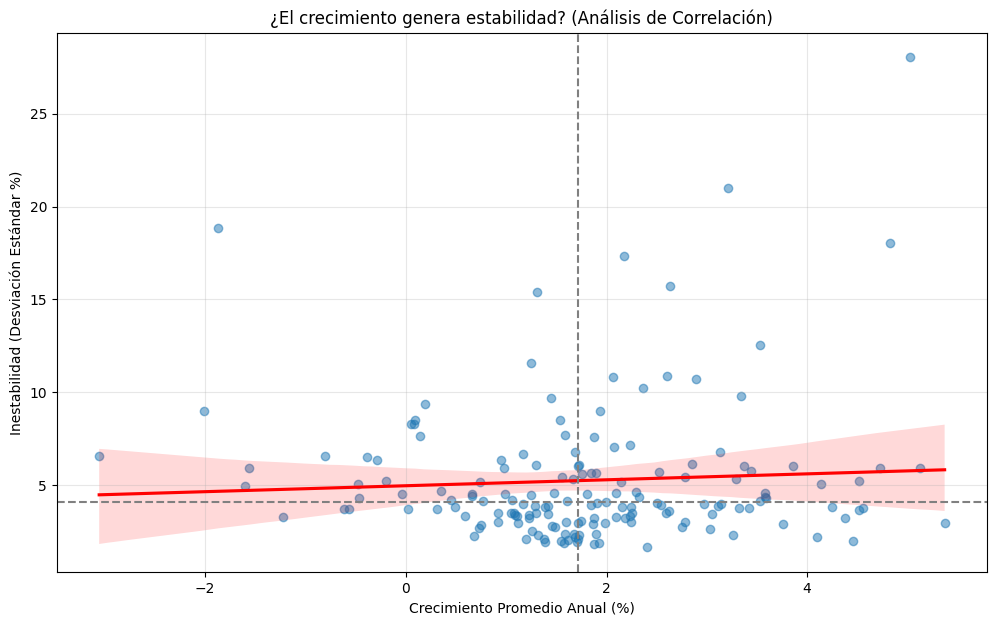

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparación de métricas
stats = df.groupby('country')['growth_rate'].agg(['mean', 'std']).dropna()
stats.columns = ['Crecimiento', 'Volatilidad']

# 2. Gráfico con Línea de Regresión
plt.figure(figsize=(12, 7))
sns.regplot(data=stats, x='Crecimiento', y='Volatilidad',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

# 3. Personalización para análisis
plt.title('¿El crecimiento genera estabilidad? (Análisis de Correlación)')
plt.axvline(stats['Crecimiento'].median(), color='gray', linestyle='--')
plt.axhline(stats['Volatilidad'].median(), color='gray', linestyle='--')

plt.xlabel('Crecimiento Promedio Anual (%)')
plt.ylabel('Inestabilidad (Desviación Estándar %)')
plt.grid(True, alpha=0.3)
plt.savefig('crecimiento_vs_estabilidad_mejorado.png')

/tmp/ipykernel_4155/3230058118.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['growth'] = df.groupby('country')['gdp_per_capita'].pct_change() * 100


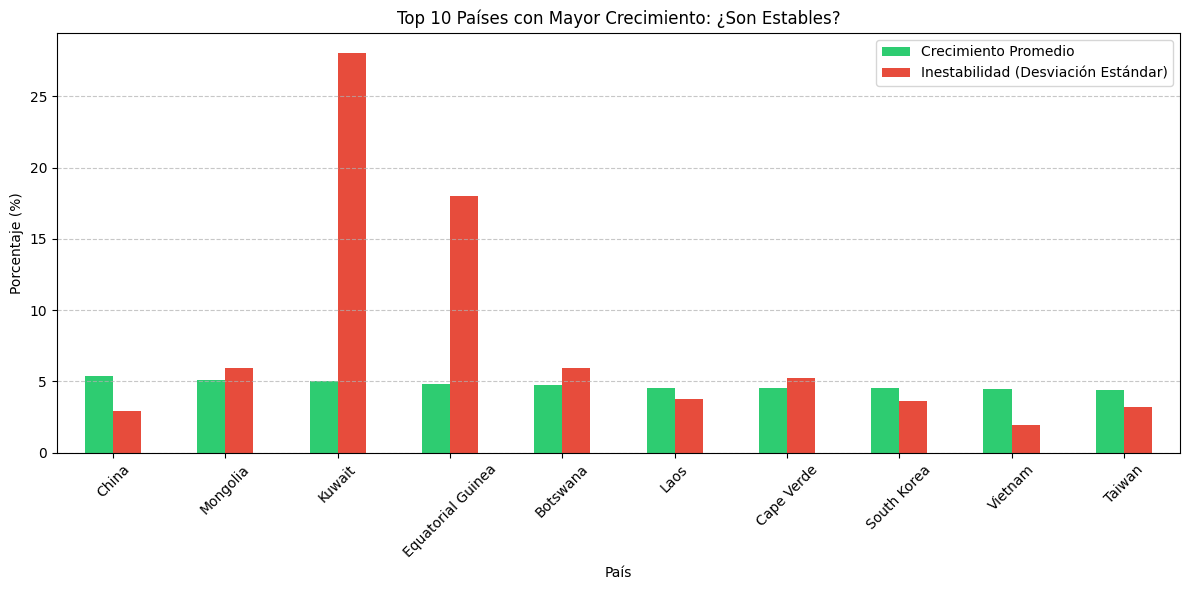

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparación de datos (Cálculos de la Clase 08/04)
df = pd.read_csv('disuguaglianza-economica-globale-e-povert-1980-2024.csv')
df = df.sort_values(['country', 'year'])
df['growth'] = df.groupby('country')['gdp_per_capita'].pct_change() * 100

# 2. Agrupación: Media para Crecimiento y Desviación Estándar para Inestabilidad
stats = df.groupby('country')['growth'].agg(['mean', 'std']).dropna()
stats.columns = ['Crecimiento', 'Inestabilidad']

# 3. Filtramos el Top 10 para que el gráfico sea legible (Clase 26/03)
top_10_growth = stats.sort_values('Crecimiento', ascending=False).head(10)

# 4. Creación del gráfico de barras agrupadas
top_10_growth.plot(kind='bar', figsize=(12, 6), color=['#2ecc71', '#e74c3c'])

plt.title('Top 10 Países con Mayor Crecimiento: ¿Son Estables?')
plt.xlabel('País')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45)
plt.legend(['Crecimiento Promedio', 'Inestabilidad (Desviación Estándar)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('barras_crecimiento_vs_estabilidad.png')

/tmp/ipykernel_4155/3057543012.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['growth'] = df.groupby('country')['gdp_per_capita'].pct_change() * 100


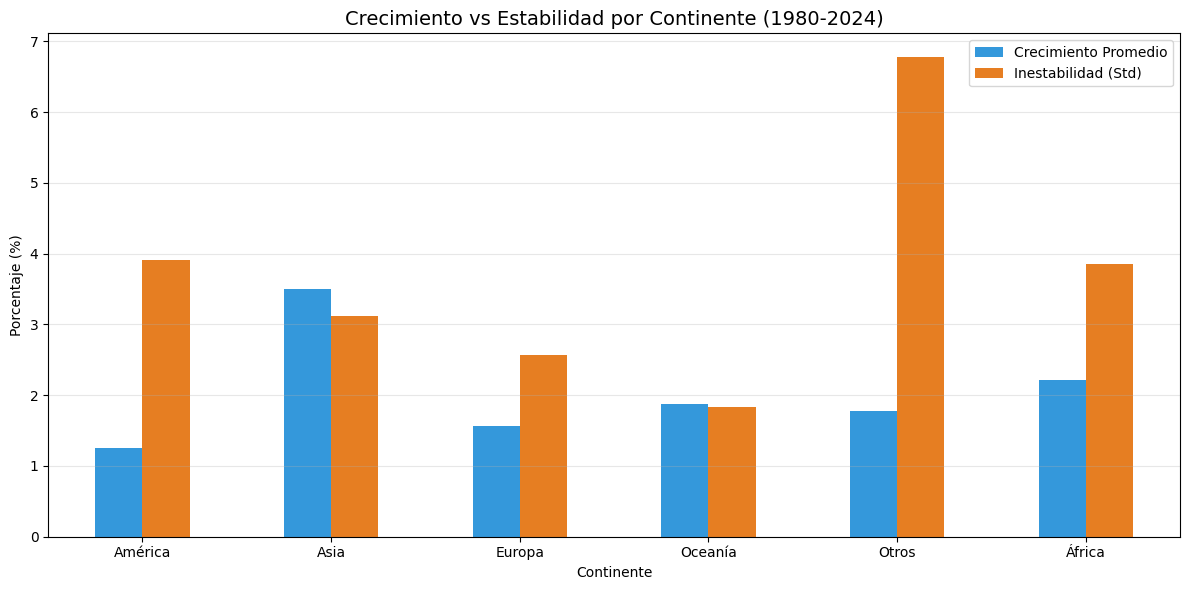

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carga y preparación
df = pd.read_csv('disuguaglianza-economica-globale-e-povert-1980-2024.csv')
df = df.sort_values(['country', 'year'])
df['growth'] = df.groupby('country')['gdp_per_capita'].pct_change() * 100

# 2. Diccionario de Mapeo (Simplificado para el ejemplo)
# En un proyecto real, usaríamos una librería como pycountry_convert
continentes = {
    'Argentina': 'América', 'Brazil': 'América', 'United States': 'América', 'Mexico': 'América',
    'China': 'Asia', 'India': 'Asia', 'Japan': 'Asia',
    'Germany': 'Europa', 'France': 'Europa', 'Spain': 'Europa', 'Italy': 'Europa',
    'Nigeria': 'África', 'Egypt': 'África', 'South Africa': 'África',
    'Australia': 'Oceanía'
}
df['continente'] = df['country'].map(continentes).fillna('Otros')

# 3. Agrupación por Continente (Clase 01/04 y 08/04)
# Calculamos la media del crecimiento y la desviación estándar (inestabilidad)
analisis_geo = df.groupby('continente')['growth'].agg(['mean', 'std']).dropna()
analisis_geo.columns = ['Crecimiento Promedio', 'Inestabilidad (Std)']

# 4. Gráfico de barras comparativo
analisis_geo.plot(kind='bar', figsize=(12, 6), color=['#3498db', '#e67e22'])

plt.title('Crecimiento vs Estabilidad por Continente (1980-2024)', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Continente')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparativa_continentes.png')

In [ ]:
import pandas as pd
import plotly.express as px

# 1. Carga y preparación (Estándar de la cátedra)
df = pd.read_csv('disuguaglianza-economica-globale-e-povert-1980-2024.csv')
df = df.sort_values(['country', 'year'])
df['growth'] = df.groupby('country')['gdp_per_capita'].pct_change() * 100

# 2. Agregación: Crecimiento y Volatilidad (Std) por País (Clase 08/04)
stats_país = df.groupby('country')['growth'].agg(['mean', 'std']).dropna().reset_index()
stats_país.columns = ['País', 'Crecimiento', 'Inestabilidad']

# 3. Enriquecimiento Regional (Mapeo)
# Gapminder ofrece un mapeo confiable que usaremos en esta agregación (Clase 18/03)
url_gapminder = "https://raw.githubusercontent.com/open-numbers/ddf--gapminder--geo_entity_domain/master/ddf--entities--geo--country.csv"
geo_data = pd.read_csv(url_gapminder)[['name', 'world_4region']]
geo_data.columns = ['País', 'Continente']

# Unimos las métricas con los continentes
stats_completo = pd.merge(stats_país, geo_data, on='País', how='left')
stats_completo['Continente'] = stats_completo['Continente'].fillna('Otros')

# 4. Creación del Gráfico INTERACTIVO y por COLORES (Plotly)
fig = px.scatter(
    stats_completo,
    x='Crecimiento',
    y='Inestabilidad',
    color='Continente', # <--- ¡Aquí cumplimos tu requerimiento!
    hover_name='País', # <--- ¡Aquí lo hacemos interactivo!
    labels={
        'Crecimiento': 'Crecimiento Promedio Anual (%)',
        'Inestabilidad': 'Inestabilidad (Volatilidad %)'
    },
    title='Crecimiento vs Estabilidad: Perspectiva Regional Global (1980-2024)'
)

# En Colab, fig.show() es necesario si no se muestra solo
fig.show()


/tmp/ipykernel_4155/3459403000.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['growth'] = df.groupby('country')['gdp_per_capita'].pct_change() * 100
